# Titanic 생존자 예측

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
data=pd.read_csv('C:\\Users\\hyang\\Documents\\titanic\\train.csv')
test=pd.read_csv('C:\\Users\\hyang\\Documents\\titanic\\test.csv')

In [3]:
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [4]:
test.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [5]:
data.describe().astype(int)       # data.describe(include='all')

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891,891,891,714,891,891,891
mean,446,0,2,29,0,0,32
std,257,0,0,14,1,0,49
min,1,0,1,0,0,0,0
25%,223,0,2,20,0,0,7
50%,446,0,3,28,0,0,14
75%,668,1,3,38,1,0,31
max,891,1,3,80,8,6,512


##  Feature 분석

### Sex

In [6]:
data.groupby(['Sex','Survived'])['Survived'].count()

Sex     Survived
female  0            81
        1           233
male    0           468
        1           109
Name: Survived, dtype: int64

In [7]:
# 성별 생존률

print("남성 생존률:", data['Sex'].loc[(data['Sex']=='male')&
                                 (data['Survived']==1)].count()/data['Sex'].loc[data['Sex']=='male'].count())
print("여성 생존률:", data['Sex'].loc[(data['Sex']=='female')&
                                 (data['Survived']==1)].count()/data['Sex'].loc[data['Sex']=='female'].count())

남성 생존률: 0.18890814558058924
여성 생존률: 0.7420382165605095


## Pclass

In [8]:
data.groupby('Pclass')['Survived'].value_counts()

Pclass  Survived
1       1           136
        0            80
2       0            97
        1            87
3       0           372
        1           119
Name: Survived, dtype: int64

In [9]:
# 선실등급별 생존률

print("1등실 생존율:", data['Pclass'].loc[(data['Pclass']==1)&
                                     (data['Survived']==1)].count()/data['Pclass'].loc[data['Pclass']==1].count())
print("2등실 생존율:", data['Pclass'].loc[(data['Pclass']==2)&
                                     (data['Survived']==1)].count()/data['Pclass'].loc[data['Pclass']==2].count())
print("3등실 생존율:", data['Pclass'].loc[(data['Pclass']==3)&
                                     (data['Survived']==1)].count()/data['Pclass'].loc[data['Pclass']==3].count())

1등실 생존율: 0.6296296296296297
2등실 생존율: 0.47282608695652173
3등실 생존율: 0.24236252545824846


In [10]:
pd.crosstab([data.Pclass, data.Sex], data.Survived, margins=True)

Survived         0    1  All
Pclass Sex                  
1      female    3   91   94
       male     77   45  122
2      female    6   70   76
       male     91   17  108
3      female   72   72  144
       male    300   47  347
All            549  342  891

In [11]:
# 선실등급*성별 생존률

print("1등실 남성 생존률:", data['Pclass'].loc[(data['Pclass']==1)&(data['Sex']=='male')&
                                              (data['Survived']==1)].count()/data['Pclass'].loc[(data['Pclass']==1)&
                                              (data['Sex']=='male')].count())
print("1등실 여성 생존률:", data['Pclass'].loc[(data['Pclass']==1)&(data['Sex']=='female')&
                                              (data['Survived']==1)].count()/data['Pclass'].loc[(data['Pclass']==1)&
                                              (data['Sex']=='female')].count(),'\n')

print("2등실 남성 생존률:", data['Pclass'].loc[(data['Pclass']==2)&(data['Sex']=='male')&
                                              (data['Survived']==1)].count()/data['Pclass'].loc[(data['Pclass']==2)&
                                              (data['Sex']=='male')].count())
print("2등실 여성 생존률:", data['Pclass'].loc[(data['Pclass']==2)&(data['Sex']=='female')&
                                              (data['Survived']==1)].count()/data['Pclass'].loc[(data['Pclass']==2)&
                                              (data['Sex']=='female')].count(),'\n')

print("3등실 남성 생존률:", data['Pclass'].loc[(data['Pclass']==3)&(data['Sex']=='male')&
                                              (data['Survived']==1)].count()/data['Pclass'].loc[(data['Pclass']==3)&
                                              (data['Sex']=='male')].count())
print("3등실 여성 생존률:", data['Pclass'].loc[(data['Pclass']==3)&(data['Sex']=='female')&
                                              (data['Survived']==1)].count()/data['Pclass'].loc[(data['Pclass']==3)&
                                              (data['Sex']=='female')].count())

1등실 남성 생존률: 0.36885245901639346
1등실 여성 생존률: 0.9680851063829787 

2등실 남성 생존률: 0.1574074074074074
2등실 여성 생존률: 0.9210526315789473 

3등실 남성 생존률: 0.13544668587896252
3등실 여성 생존률: 0.5


- 선실등급이 높을수록 생존률이 높음
- 여성 탑승객: 2등선실과 3등선실 간 생존률 차이가 매우 높음
- 남성 탑승객: 2등선실과 3등선실 간 생존률 차이가 크지 않음. 오히려 1등선실과 2등선실 간 생존률 차이가 큼

### Age

In [12]:
print('가장 나이 많은 승객 :', data['Age'].max())
print('가장 어린 승객', data['Age'].min())
print('탑승객의 평균 나이', data['Age'].mean())

가장 나이 많은 승객 : 80.0
가장 어린 승객 0.42
탑승객의 평균 나이 29.69911764705882


- 2, 3등급 탑승자들 중 연령이 낮은 아이들이 많이 살아남음 
- 희생자들의 연령대는 3등급보다는 2등급, 2등급보다는 1등급이 더 높아짐
- 이는 생존자들의 연령대도 유사함

### Embarked

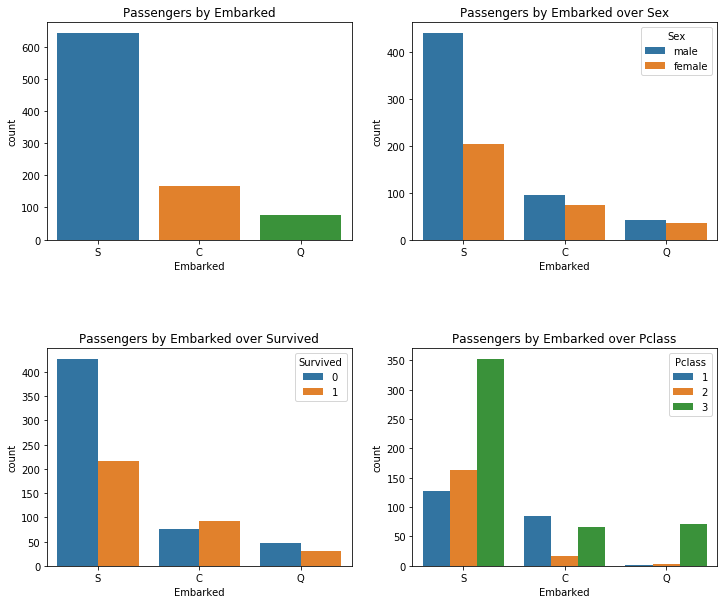

In [13]:
fig,ax = plt.subplots(2,2, figsize= (12,10))

sns.countplot("Embarked", data=data, ax=ax[0,0])
ax[0,0].set_title("Passengers by Embarked")

sns.countplot('Embarked', hue='Sex', data=data, ax=ax[0,1])
ax[0,1].set_title('Passengers by Embarked over Sex')

sns.countplot('Embarked', hue='Survived', data=data, ax=ax[1,0])
ax[1,0].set_title('Passengers by Embarked over Survived')

sns.countplot('Embarked', hue ='Pclass', data=data, ax=ax[1,1])
ax[1,1].set_title('Passengers by Embarked over Pclass')

plt.subplots_adjust(wspace=0.2, hspace=0.5)
plt.show()

In [14]:
pd.crosstab(data.Embarked, data.Pclass, margins=True)

Pclass,1,2,3,All
Embarked,,,,
C,85,17,66,168
Q,2,3,72,77
S,127,164,353,644
All,214,184,491,889


In [15]:
# 탑승항구별 선실등급 비율

print("C항구, 1등선실:", data['Pclass'].loc[(data['Pclass']==1)&
                        (data['Embarked']=='C')].count()/data['Pclass'].loc[data['Embarked']=='C'].count())
print("C항구, 2등선실:", data['Pclass'].loc[(data['Pclass']==2)&
                        (data['Embarked']=='C')].count()/data['Pclass'].loc[data['Embarked']=='C'].count())
print("C항구, 3등선실:", data['Pclass'].loc[(data['Pclass']==3)&
                        (data['Embarked']=='C')].count()/data['Pclass'].loc[data['Embarked']=='C'].count(),'\n')

print("Q항구, 1등선실:", data['Pclass'].loc[(data['Pclass']==1)&
                        (data['Embarked']=='Q')].count()/data['Pclass'].loc[data['Embarked']=='Q'].count())
print("Q항구, 2등선실:", data['Pclass'].loc[(data['Pclass']==2)&
                        (data['Embarked']=='Q')].count()/data['Pclass'].loc[data['Embarked']=='Q'].count())
print("Q항구, 3등선실:", data['Pclass'].loc[(data['Pclass']==3)&
                        (data['Embarked']=='Q')].count()/data['Pclass'].loc[data['Embarked']=='Q'].count(),'\n')

print("S항구, 1등선실:", data['Pclass'].loc[(data['Pclass']==1)&
                        (data['Embarked']=='S')].count()/data['Pclass'].loc[data['Embarked']=='S'].count())
print("S항구, 2등선실:", data['Pclass'].loc[(data['Pclass']==2)&
                        (data['Embarked']=='S')].count()/data['Pclass'].loc[data['Embarked']=='S'].count())
print("S항구, 3등선실:", data['Pclass'].loc[(data['Pclass']==3)&
                        (data['Embarked']=='S')].count()/data['Pclass'].loc[data['Embarked']=='S'].count())

C항구, 1등선실: 0.5059523809523809
C항구, 2등선실: 0.10119047619047619
C항구, 3등선실: 0.39285714285714285 

Q항구, 1등선실: 0.025974025974025976
Q항구, 2등선실: 0.03896103896103896
Q항구, 3등선실: 0.935064935064935 

S항구, 1등선실: 0.1972049689440994
S항구, 2등선실: 0.2546583850931677
S항구, 3등선실: 0.5481366459627329


#### 관찰 내용 

- 탑승객의 수는 Port S에서 탑승한 승객이 가장 많고, Port Q에서 탑승한 승객이 가장 적다. 
- Port S에서 탑승한 승객의 생존률이 가장 낮고, Port C에서 탑승한 승객의 생존률이 가장 높음
- Port S에서 탑승한 승객들은 3등급 선실 이용이 가장 많은 반면 Port C에서 탑승한 승객들은 1등급 선실 이용률이 가장 높음 
- Port S에서 탑승한 승객의 생존률보다 Port C에서 탑승한 승객의 생존률이 더 높은 이유는 선실등급 차이 때문인 듯.

In [16]:
# 탑승항구별 생존률

print("C Port 탑승자 생존율:", data['Embarked'].loc[(data['Embarked']=='C')&
                             (data['Survived']==1)].count()/data['Embarked'].loc[data['Embarked']=='C'].count())
print("Q Port 탑승자 생존율:", data['Embarked'].loc[(data['Embarked']=='Q')&
                             (data['Survived']==1)].count()/data['Embarked'].loc[data['Embarked']=='Q'].count())
print("S Port 탑승자 생존율:", data['Embarked'].loc[(data['Embarked']=='S')&
                             (data['Survived']==1)].count()/data['Embarked'].loc[data['Embarked']=='S'].count())

C Port 탑승자 생존율: 0.5535714285714286
Q Port 탑승자 생존율: 0.38961038961038963
S Port 탑승자 생존율: 0.33695652173913043


In [17]:
pd.crosstab([data.Embarked, data.Pclass],data.Survived,margins=True)

Survived           0    1  All
Embarked Pclass               
C        1        26   59   85
         2         8    9   17
         3        41   25   66
Q        1         1    1    2
         2         1    2    3
         3        45   27   72
S        1        53   74  127
         2        88   76  164
         3       286   67  353
All              549  340  889

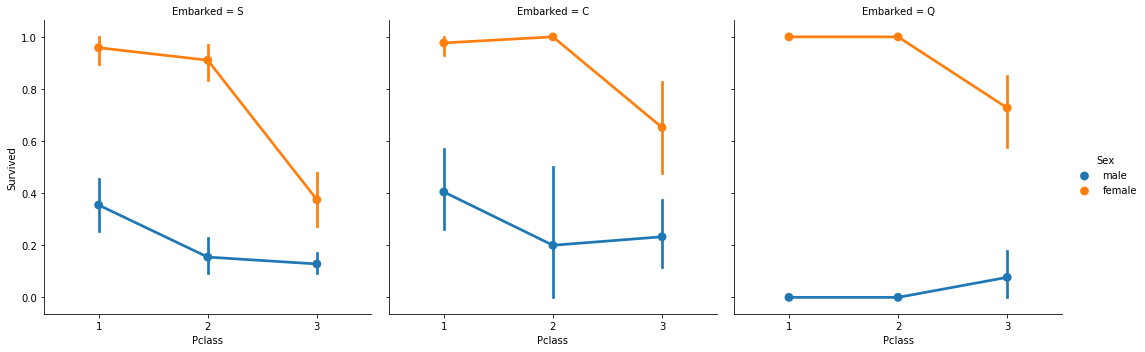

In [18]:
sns.factorplot('Pclass','Survived', hue = 'Sex', col = 'Embarked', data= data)
plt.show()

## SibSp

In [19]:
pd.crosstab(data.SibSp, data.Survived, margins=True)

Survived,0,1,All
SibSp,,,
0,398,210,608
1,97,112,209
2,15,13,28
3,12,4,16
4,15,3,18
5,5,0,5
8,7,0,7
All,549,342,891


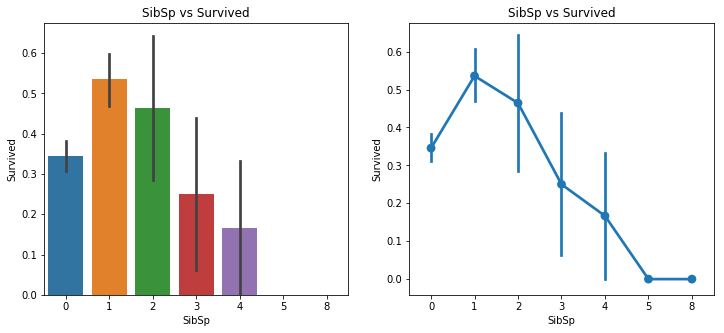

In [20]:
fig, ax= plt.subplots(1, 2, figsize =(12,5))

sns.barplot('SibSp','Survived',data=data,ax=ax[0])
ax[0].set_title('SibSp vs Survived')

sns.factorplot('SibSp','Survived',data = data, ax=ax[1])
ax[1].set_title('SibSp vs Survived')

plt.close(2)
plt.show()

In [21]:
pd.crosstab(data.SibSp, data.Pclass, margins=True)

Pclass,1,2,3,All
SibSp,,,,
0,137,120,351,608
1,71,55,83,209
2,5,8,15,28
3,3,1,12,16
4,0,0,18,18
5,0,0,5,5
8,0,0,7,7
All,216,184,491,891


####  관찰
1. 동승한 sibling이 없다면 35%의 생존률을 보임
2. 동승한 sibling이 많을수록 생존률이 감소함 
3. 동승한 sibling의 숫자가 많아질수록 3등급 선실을 이용함. 

### Fare

In [22]:
print('가장 높은 가격:', data.Fare.max())
print('가장 낮은 가격:', data.Fare.min())
print('평균 가격:', data.Fare.mean())

가장 높은 가격: 512.3292
가장 낮은 가격: 0.0
평균 가격: 32.2042079685746


In [23]:
data.groupby(['Pclass','Survived'])['Fare'].mean()

Pclass  Survived
1       0           64.684008
        1           95.608029
2       0           19.412328
        1           22.055700
3       0           13.669364
        1           13.694887
Name: Fare, dtype: float64

#### 관찰결과
- 선실등급(1,2 등급) 내에서도 생존자와 사망자 간 평균요금 차이가 남: 이는 Fare가 선실등급을 통한 영향 외에 추가적으로 생존여부에 영향을 미친 것으로 보임

### Features에 대한 종합 관찰 결과 : 예측모델에 포함시킨 Features
  1. Sex : 여성이 남성보다 생존률이 더 높다. 
  2. Pclass : 1등급 탑승자의 생존률이 가장 높고, 3등급 탑승객의 생존률이 가장 낮다. 
  3. Age : 5살 이하 아이들의 생존률이 높은 반면 15~35살 사이의 승객들의 생존률이 낮았다. 
  4. Embarked : Port C에서 탑승한 승객의 생존률이 가장 높다.
  5. SibSp : 함께 탑승한 SibSp의 숫자가 클수록 생존률이 낮다. 
  6. Fare : Fare가 높을수록 생존률이 높다. 

## Feature engineering 

### Embarked

In [24]:
data['Embarked'].fillna('S', inplace=True)

In [25]:
print(sum(data['Embarked'].isnull()))

0


In [26]:
data.Name.values

array(['Braund, Mr. Owen Harris',
       'Cumings, Mrs. John Bradley (Florence Briggs Thayer)',
       'Heikkinen, Miss. Laina',
       'Futrelle, Mrs. Jacques Heath (Lily May Peel)',
       'Allen, Mr. William Henry', 'Moran, Mr. James',
       'McCarthy, Mr. Timothy J', 'Palsson, Master. Gosta Leonard',
       'Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)',
       'Nasser, Mrs. Nicholas (Adele Achem)',
       'Sandstrom, Miss. Marguerite Rut', 'Bonnell, Miss. Elizabeth',
       'Saundercock, Mr. William Henry', 'Andersson, Mr. Anders Johan',
       'Vestrom, Miss. Hulda Amanda Adolfina',
       'Hewlett, Mrs. (Mary D Kingcome) ', 'Rice, Master. Eugene',
       'Williams, Mr. Charles Eugene',
       'Vander Planke, Mrs. Julius (Emelia Maria Vandemoortele)',
       'Masselmani, Mrs. Fatima', 'Fynney, Mr. Joseph J',
       'Beesley, Mr. Lawrence', 'McGowan, Miss. Anna "Annie"',
       'Sloper, Mr. William Thompson', 'Palsson, Miss. Torborg Danira',
       'Asplund, Mrs. Carl Oscar 

In [27]:
data['Initial']=data.Name.str.extract('([A-Za-z]+)\.')
data['Initial'].replace(['Mlle','Mme','Ms','Major','Lady','Countess','Jonkheer','Col','Rev','Capt','Sir','Don'],
                        ['Miss','Miss','Miss','Mr','Mrs','Mrs','Other','Other','Mr','Mr','Mr','Mr'],inplace=True)

pd.crosstab(data.Initial,data.Sex).T

Initial,Dr,Master,Miss,Mr,Mrs,Other
Sex,,,,,,
female,1,0,186,0,127,0
male,6,40,0,528,0,3


In [28]:
test['Initial']=test.Name.str.extract('([A-Za-z]+)\.')
test['Initial'].replace(['Mlle','Mme','Ms','Major','Lady','Countess','Jonkheer','Col','Rev','Capt','Sir','Don', 'Dona'],
                        ['Miss','Miss','Miss','Mr','Mrs','Mrs','Other','Other','Mr','Mr','Mr','Mr', 'Mrs'], inplace=True)

pd.crosstab(test.Initial, test.Sex).T

Initial,Dr,Master,Miss,Mr,Mrs,Other
Sex,,,,,,
female,0,0,79,0,73,0
male,1,21,0,242,0,2


In [29]:
# Training data: missing Age를 대체값으로 채워넣기

data.loc[(data.Age.isnull())&(data.Initial=='Mr'),'Age'] = 32
data.loc[(data.Age.isnull())&(data.Initial=='Mrs'),'Age'] = 35
data.loc[(data.Age.isnull())&(data.Initial=='Master'),'Age'] = 4
data.loc[(data.Age.isnull())&(data.Initial=='Miss'),'Age'] = 21
data.loc[(data.Age.isnull())&(data.Initial=='Other'),'Age'] = 51
data.loc[(data.Age.isnull())&(data.Initial=='Dr'), 'Age']=42

In [30]:
data.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Initial
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs


### Categorical features를 더미 변수로 만들기

In [31]:
# 성별을 더미변수(0,1)로 만들기

data['Sex']=data['Sex'].map({'male':1, 'female':0})

In [32]:
# 카테고리 변수를 더미 변수로 전환하기

Pclass_dummy=pd.get_dummies(data=data['Pclass'], prefix='Pclass')
Port_dummy=pd.get_dummies(data=data['Embarked'], prefix='Port')
Initial_dummy=pd.get_dummies(data=data['Initial'], prefix=None)

In [33]:
# 더미 변수를 원데이터에 붙이기

data=data.join(Pclass_dummy)
data=data.join(Port_dummy)
data=data.join(Initial_dummy)

data=data.drop(['Pclass','Embarked', 'Initial'], axis=1)

In [34]:
data.head(2)

,PassengerId,Survived,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,...,Pclass_3,Port_C,Port_Q,Port_S,Dr,Master,Miss,Mr,Mrs,Other
0,1,0,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,...,1,0,0,1,0,0,0,1,0,0
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,...,0,1,0,0,0,0,0,0,1,0


In [35]:
data.columns

Index(['PassengerId', 'Survived', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Pclass_1', 'Pclass_2', 'Pclass_3', 'Port_C',
       'Port_Q', 'Port_S', 'Dr', 'Master', 'Miss', 'Mr', 'Mrs', 'Other'],
      dtype='object')

In [36]:
data.drop(['PassengerId', 'Name', 'Ticket', 'Cabin', 'Parch', 'Age'], axis=1, inplace=True)
data.isnull().sum()

Survived    0
Sex         0
SibSp       0
Fare        0
Pclass_1    0
Pclass_2    0
Pclass_3    0
Port_C      0
Port_Q      0
Port_S      0
Dr          0
Master      0
Miss        0
Mr          0
Mrs         0
Other       0
dtype: int64

## 머신러닝 적용하기

In [37]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn import metrics 
from sklearn.model_selection import train_test_split

In [38]:
X_train=data.drop('Survived',axis=1).values
X_train

array([[ 1.    ,  1.    ,  7.25  , ...,  1.    ,  0.    ,  0.    ],
       [ 0.    ,  1.    , 71.2833, ...,  0.    ,  1.    ,  0.    ],
       [ 0.    ,  0.    ,  7.925 , ...,  0.    ,  0.    ,  0.    ],
       ...,
       [ 0.    ,  1.    , 23.45  , ...,  0.    ,  0.    ,  0.    ],
       [ 1.    ,  0.    , 30.    , ...,  1.    ,  0.    ,  0.    ],
       [ 1.    ,  0.    ,  7.75  , ...,  1.    ,  0.    ,  0.    ]])

In [39]:
y_train = data['Survived'].values
y_train

array([0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1,

### Training Data에서 Validation Data를 분리 (검증)

In [40]:
#X_tr,X_vld,y_tr,y_vld = train_test_split(X_train, y_train, test_size = 0.2, random_state=1)

In [41]:
RF = RandomForestClassifier()
RF.fit(X_train,y_train)
prediction = RF.predict(X_train)
Accuracy_RF=metrics.accuracy_score(prediction,y_train)

In [42]:
LogReg = LogisticRegression()
LogReg.fit(X_train,y_train)
prediction = LogReg.predict(X_train)
Accuracy_Logistic= metrics.accuracy_score(prediction,y_train)

In [43]:
MLP = MLPClassifier()
MLP.fit(X_train, y_train)
prediction = MLP.predict(X_train)
Accuracy_MLP = metrics.accuracy_score(prediction, y_train)

In [44]:
SVC = SVC()
SVC.fit(X_train, y_train)
prediction = SVC.predict(X_train)
Accuracy_SVC = metrics.accuracy_score(prediction,y_train)

In [45]:
Ada = AdaBoostClassifier()
Ada.fit(X_train, y_train)
prediction = Ada.predict(X_train)
Accuracy_Ada = metrics.accuracy_score(prediction, y_train)

In [46]:
NB = GaussianNB()
NB.fit(X_train, y_train)
prediction = NB.predict(X_train)
Accuracy_NB = metrics.accuracy_score(prediction, y_train)

In [47]:
KN = KNeighborsClassifier()
KN.fit(X_train, y_train)
prediction = KN.predict(X_train)
Accuracy_KN = metrics.accuracy_score(prediction, y_train)

In [48]:
print("Accuracy_RF:", Accuracy_RF) 
print("Accuracy_Logistic:", Accuracy_Logistic) 
print("Accuracy_MLP:", Accuracy_MLP) 
print("Accuracy_SVC:", Accuracy_SVC) 
print("Accuracy_Ada:", Accuracy_Ada) 
print("Accuracy_NB:", Accuracy_NB) 
print("Accuracy_KN:", Accuracy_KN) 

Accuracy_RF: 0.9180695847362514
Accuracy_Logistic: 0.8237934904601572
Accuracy_MLP: 0.835016835016835
Accuracy_SVC: 0.8338945005611672
Accuracy_Ada: 0.8327721661054994
Accuracy_NB: 0.8170594837261503
Accuracy_KN: 0.8417508417508418


### Submission

In [49]:
test.head(3)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Initial
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,Mr
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,Mrs
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,Mr


In [50]:
test.groupby('Pclass')['Fare'].mean()

Pclass
1    94.280297
2    22.202104
3    12.459678
Name: Fare, dtype: float64

In [51]:
test.loc[(test.Fare.isnull())&(test.Pclass==1), 'Fare']=94.28
test.loc[(test.Fare.isnull())&(test.Pclass==2), 'Fare']=22.20
test.loc[(test.Fare.isnull())&(test.Pclass==3), 'Fare']=12.46

In [52]:
test['Sex']=test['Sex'].map({'male':1, 'female':0})

In [53]:
Pclass_dummy=pd.get_dummies(data=test['Pclass'], prefix='Pclass')
Port_dummy=pd.get_dummies(data=test['Embarked'], prefix='Port')
Initial_dummy=pd.get_dummies(data=test['Initial'], prefix=None)

test=test.join(Pclass_dummy)
test=test.join(Port_dummy)
test=test.join(Initial_dummy)

test=test.drop(['Pclass','Embarked', 'Initial'], axis=1)

test.drop(['PassengerId', 'Name', 'Ticket', 'Cabin', 'Parch', 'Age'], axis=1, inplace=True)

In [54]:
test.head(3)

,Sex,SibSp,Fare,Pclass_1,Pclass_2,Pclass_3,Port_C,Port_Q,Port_S,Dr,Master,Miss,Mr,Mrs,Other
0,1,0,7.8292,0,0,1,0,1,0,0,0,0,1,0,0
1,0,1,7.0000,0,0,1,0,0,1,0,0,0,0,1,0
2,1,0,9.6875,0,1,0,0,1,0,0,0,0,1,0,0


In [55]:
X_test = test.values
X_test

array([[ 1.    ,  0.    ,  7.8292, ...,  1.    ,  0.    ,  0.    ],
       [ 0.    ,  1.    ,  7.    , ...,  0.    ,  1.    ,  0.    ],
       [ 1.    ,  0.    ,  9.6875, ...,  1.    ,  0.    ,  0.    ],
       ...,
       [ 1.    ,  0.    ,  7.25  , ...,  1.    ,  0.    ,  0.    ],
       [ 1.    ,  0.    ,  8.05  , ...,  1.    ,  0.    ,  0.    ],
       [ 1.    ,  1.    , 22.3583, ...,  0.    ,  0.    ,  0.    ]])

In [56]:
submission = pd.read_csv('C:\\Users\\hyang\\Documents\\titanic\\gender_submission.csv')

In [57]:
submission.head(3)

,PassengerId,Survived
0,892,0
1,893,1
2,894,0


In [58]:
y_test = submission['Survived'].values
y_test

array([0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [59]:
test.columns

Index(['Sex', 'SibSp', 'Fare', 'Pclass_1', 'Pclass_2', 'Pclass_3', 'Port_C',
       'Port_Q', 'Port_S', 'Dr', 'Master', 'Miss', 'Mr', 'Mrs', 'Other'],
      dtype='object')

In [60]:
prediction1 = RF.predict(X_test)
Accuracy_RF=metrics.accuracy_score(prediction1, y_test)
prediction2 = LogReg.predict(X_test)
Accuracy_Logistic= metrics.accuracy_score(prediction2,y_test)
prediction3 = MLP.predict(X_test)
Accuracy_MLP = metrics.accuracy_score(prediction3, y_test)
prediction4 = SVC.predict(X_test)
Accuracy_SVC = metrics.accuracy_score(prediction4,y_test)
prediction5 = Ada.predict(X_test)
Accuracy_Ada = metrics.accuracy_score(prediction5, y_test)
prediction6 = NB.predict(X_test)
Accuracy_NB = metrics.accuracy_score(prediction6, y_test)
prediction7 = KN.predict(X_test)
Accuracy_KN = metrics.accuracy_score(prediction7, y_test)

In [61]:
print("Accuracy_RF:", Accuracy_RF) 
print("Accuracy_Logistic:", Accuracy_Logistic) 
print("Accuracy_MLP:", Accuracy_MLP) 
print("Accuracy_SVC:", Accuracy_SVC) 
print("Accuracy_Ada:", Accuracy_Ada) 
print("Accuracy_NB:", Accuracy_NB) 
print("Accuracy_KN:", Accuracy_KN) 

Accuracy_RF: 0.8373205741626795
Accuracy_Logistic: 0.9425837320574163
Accuracy_MLP: 0.8803827751196173
Accuracy_SVC: 0.8923444976076556
Accuracy_Ada: 0.916267942583732
Accuracy_NB: 0.916267942583732
Accuracy_KN: 0.8038277511961722


In [63]:
prediction2 = LogReg.predict(X_test)
submission['Survived'] = prediction2

In [64]:
submission.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [65]:
submission.to_csv('C:\\Users\\hyang\\Documents\\titanic\\[191110]titanic_first.csv', index=False)